In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv('CarDataset.csv')

In [4]:
df.shape

(301, 9)

In [6]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [14]:
df['Fuel_Type'].nunique()

3

In [15]:
#How many different vehicles are present in this data?
df['Car_Name'].nunique()

98

In [16]:
#Which is the most sold vehicle?
df['Car_Name'].value_counts().idxmax()

'city'

In [18]:
df['Car_Name'].value_counts().head(1)

Car_Name
city    26
Name: count, dtype: int64

In [19]:
#Does the dataset include any CNG Vehicle? If yes, how many?
(df['Fuel_Type'].str.upper() == 'CNG').sum()

np.int64(2)

In [20]:
#How many vehicles here are for sell from individuals directly?
(df['Seller_Type'] == 'Individual').sum()

np.int64(106)

In [22]:
#Does this database contain auto transmission vehicles? If yes how many of them are there?
(df['Transmission'] == 'Automatic').sum()

np.int64(40)

In [25]:
#How many single person owned vehicles are there in this database?
(df['Owner'] == 1).sum()

np.int64(10)

In [26]:
(df['Owner'] == 0).sum()

np.int64(290)

In [27]:
(df['Owner'] == 3).sum()

np.int64(1)

In [28]:
#Which is the most and least cost depreciated vehicle in the data?
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']

In [31]:
df.loc[df['Depreciation'].idxmax(), ['Car_Name', 'Depreciation']]

Car_Name        land cruiser
Depreciation            57.6
Name: 86, dtype: object

In [30]:
df.loc[df['Depreciation'].idxmin(), ['Car_Name', 'Depreciation']]

Car_Name        Honda Activa 4G
Depreciation               0.03
Name: 155, dtype: object

In [32]:
#Which brands of vehicles are least affected by Depreciation?
df['Brand'] = df['Car_Name'].str.split().str[0]
df.groupby('Brand') ['Depreciation'].mean().sort_values()

Brand
UM           0.120000
Activa       0.183333
TVS          0.242750
Mahindra     0.250000
Yamaha       0.258750
Hero         0.265200
Honda        0.318824
Suzuki       0.330000
Bajaj        0.334400
Royal        0.423529
vitara       0.580000
KTM          0.745000
grand        0.756250
ignis        0.810000
alto         1.166667
brio         1.299000
omni         1.440000
i10          1.506000
eon          1.530000
creta        1.800000
swift        1.802000
800          1.930000
wagon        1.937500
baleno       2.020000
Hyosung      2.100000
s            2.110000
xcent        2.163333
ciaz         2.284444
jazz         2.328571
i20          2.438889
ritz         2.475000
amaze        2.564286
etios        2.848182
ertiga       2.848333
dzire        3.157500
elantra      3.190000
verna        3.292143
city         4.372692
sx4          4.908333
innova       5.068889
corolla     10.425882
fortuner    12.047273
camry       21.230000
land        57.600000
Name: Depreciation, dtype:

In [33]:
#Are there any factor which you feel affected the cost depreciation?
#Yes, In this dataset several factors can affect cost Depreciation.
df.groupby('Year') ['Depreciation'].mean()

Year
2003     3.830000
2004    10.850000
2005     6.997500
2006     7.620000
2007     0.505000
2008     3.756714
2009     7.785000
2010     9.068000
2011     2.772789
2012     4.143478
2013     3.280212
2014     3.075868
2015     2.254918
2016     1.337600
2017     0.799429
2018     0.580000
Name: Depreciation, dtype: float64

df.groupby('Fuel_Type') ['Depreciation'].mean()

In [35]:
#In general selling price is affected by age of vehicle and distance driven by vehicle, is it observable from data?
df['Age'] = 2026 - df['Year']

In [37]:
df.groupby('Age')['Selling_Price'].mean()

Age
8     9.250000
9     6.209143
10    5.213200
11    5.927049
12    4.762105
13    3.540909
14    3.841304
15    2.375263
16    5.262667
17    2.816667
18    1.002857
19    0.160000
20    1.437500
21    2.487500
22    1.500000
23    1.300000
Name: Selling_Price, dtype: float64

In [38]:
df.groupby('Kms_Driven')['Selling_Price'].mean()

Kms_Driven
500       0.585
1000      0.450
1200      1.450
1300      0.650
1400      1.700
          ...  
135154    1.500
142000    2.500
197176    3.490
213000    0.310
500000    0.170
Name: Selling_Price, Length: 206, dtype: float64

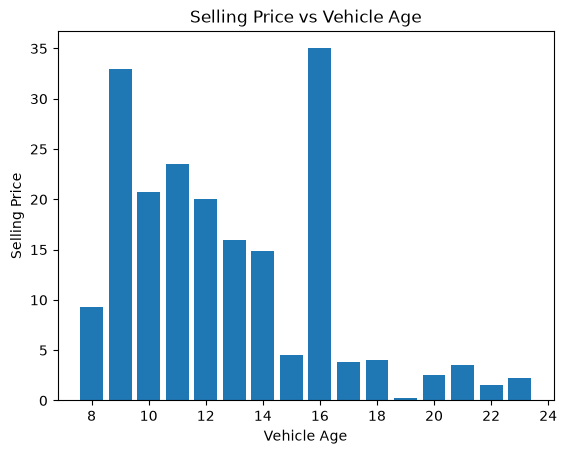

In [41]:
plt.bar(df['Age'], df['Selling_Price'])
plt.xlabel('Vehicle Age')
plt.ylabel('Selling Price')
plt.title('Selling Price vs Vehicle Age')
plt.show()

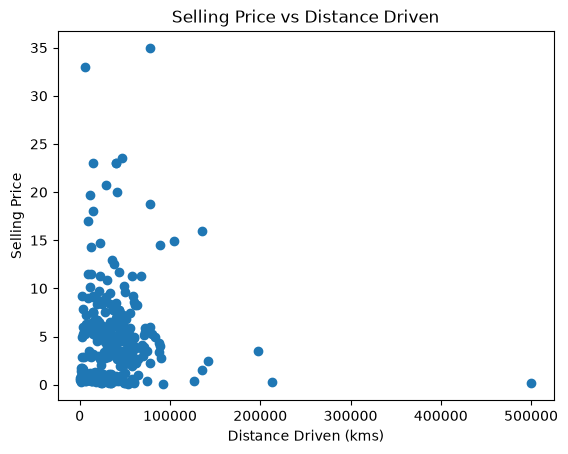

In [42]:
plt.scatter(df['Kms_Driven'], df['Selling_Price'])
plt.xlabel('Distance Driven (kms)')
plt.ylabel('Selling Price')
plt.title('Selling Price vs Distance Driven')
plt.show()

In [5]:
#Can we get idea about newest vehicles i.e after 2014 manufactured? 
df[df['Year'] > 2014]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
295,city,2015,8.55,13.09,60076,Diesel,Dealer,Manual,0
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [6]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [7]:
#Can we get data of only two-wheelers from this data?
#Yes, two-wheeler data is present in the dataset. Vehicles such as KTM RC200 and Royal Enfield are two-wheelers. Since the dataset does not have a separate vehicle-type column, two-wheelers can be identified using the Car_Name column.
df['Car_Name'].unique()

<ArrowStringArray>
[                     'ritz',                       'sx4',
                      'ciaz',                   'wagon r',
                     'swift',             'vitara brezza',
                   's cross',                  'alto 800',
                    'ertiga',                     'dzire',
                  'alto k10',                     'ignis',
                       '800',                    'baleno',
                      'omni',                  'fortuner',
                    'innova',             'corolla altis',
               'etios cross',                   'etios g',
                'etios liva',                   'corolla',
                  'etios gd',                     'camry',
              'land cruiser', 'Royal Enfield Thunder 500',
        'UM Renegade Mojave',                 'KTM RC200',
         'Bajaj Dominar 400', 'Royal Enfield Classic 350',
                 'KTM RC390',            'Hyosung GT250R',
 'Royal Enfield Thunder 350',        

In [8]:
bike_names = [
    'Royal Enfield Thunder 500',
    'UM Renegade Mojave',
    'KTM RC200',
    'Bajaj Dominar 400',
    'Royal Enfield Classic 350',
    'KTM RC390',
    'Hyosung GT250R',
    'Royal Enfield Thunder 350',
    'KTM 390 Duke ',
    'Mahindra Mojo XT300',
    'Bajaj Pulsar RS200',
    'Royal Enfield Bullet 350',
    'Royal Enfield Classic 500',
    'Bajaj Avenger 220',
    'Bajaj Avenger 150',
    'Honda CB Hornet 160R',
    'Yamaha FZ S V 2.0',
    'Yamaha FZ 16',
    'TVS Apache RTR 160',
    'Bajaj Pulsar 150',
    'Honda CBR 150',
    'Hero Extreme',
    'Bajaj Avenger 220 dtsi',
    'Bajaj Avenger 150 street',
    'Yamaha FZ  v 2.0',
    'Bajaj Pulsar  NS 200',
    'Bajaj Pulsar 220 F',
    'TVS Apache RTR 180',
    'Hero Passion X pro',
    'Bajaj Pulsar NS 200',
    'Yamaha Fazer ',
    'Honda Activa 4G',
    'TVS Sport ',
    'Honda Dream Yuga ',
    'Bajaj Avenger Street 220',
    'Hero Splender iSmart',
    'Activa 3g',
    'Hero Passion Pro',
    'Honda CB Trigger',
    'Yamaha FZ S ',
    'Bajaj Pulsar 135 LS',
    'Activa 4g',
    'Honda CB Unicorn',
    'Hero Honda CBZ extreme',
    'Honda Karizma',
    'Honda Activa 125',
    'TVS Jupyter',
    'Hero Honda Passion Pro',
    'Hero Splender Plus',
    'Honda CB Shine',
    'Bajaj Discover 100',
    'Suzuki Access 125',
    'TVS Wego',
    'Honda CB twister',
    'Hero Glamour',
    'Hero Super Splendor',
    'Bajaj Discover 125',
    'Hero Hunk',
    'Hero  Ignitor Disc',
    'Hero  CBZ Xtreme',
    'Bajaj  ct 100'
]


In [9]:
#Which is the oldest bike solded here?
bikes = df[df['Car_Name'].isin(bike_names)]
bikes.loc[bikes['Year'].idxmin(), ['Car_Name', 'Year', 'Selling_Price']]

Car_Name         Hero Super Splendor
Year                            2005
Selling_Price                    0.2
Name: 189, dtype: object

In [10]:
#which is the newest bike sold here?
bikes[['Car_Name', 'Year', 'Selling_Price']].sort_values('Year', ascending=False).head()

,Car_Name,Year,Selling_Price
101,UM Renegade Mojave,2017,1.70
103,Bajaj Dominar 400,2017,1.45
102,KTM RC200,2017,1.65
104,Royal Enfield Classic 350,2017,1.35
109,Royal Enfield Classic 350,2017,1.20


In [12]:
#which is the most sold bike here?
bikes['Car_Name'].value_counts().idxmax()

'Royal Enfield Classic 350'

In [13]:
#Do you find any deal in two wheelers which is exceeded the general expectation? Can you find reason for it?
# Find two-wheelers with unusually high selling prices
bikes.sort_values('Selling_Price', ascending=False)[
    ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']
].head(10)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner
100,Royal Enfield Thunder 500,2016,1.75,1.90,3000,0
101,UM Renegade Mojave,2017,1.70,1.82,1400,0
102,KTM RC200,2017,1.65,1.78,4000,0
103,Bajaj Dominar 400,2017,1.45,1.60,1200,0
104,Royal Enfield Classic 350,2017,1.35,1.47,4100,0
105,KTM RC390,2015,1.35,2.37,21700,0
106,Hyosung GT250R,2014,1.35,3.45,16500,1
107,Royal Enfield Thunder 350,2013,1.25,1.50,15000,0
108,Royal Enfield Thunder 350,2016,1.20,1.50,18000,0
109,Royal Enfield Classic 350,2017,1.20,1.47,11000,0


In [14]:
bikes['Price_Ratio'] = bikes['Selling_Price'] / bikes['Present_Price']

bikes.sort_values('Price_Ratio', ascending=False)[
    ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Price_Ratio']
].head()

,Car_Name,Year,Selling_Price,Present_Price,Price_Ratio
126,Bajaj Avenger 220,2017,0.90,0.95,0.947368
155,Honda Activa 4G,2017,0.48,0.51,0.941176
127,Bajaj Avenger 150,2016,0.75,0.80,0.937500
101,UM Renegade Mojave,2017,1.70,1.82,0.934066
129,Yamaha FZ S V 2.0,2017,0.78,0.84,0.928571


In [15]:
bikes.loc[bikes['Price_Ratio'].idxmax()]

Car_Name         Bajaj Avenger 220
Year                          2017
Selling_Price                  0.9
Present_Price                 0.95
Kms_Driven                    1300
Fuel_Type                   Petrol
Seller_Type             Individual
Transmission                Manual
Owner                            0
Price_Ratio               0.947368
Name: 126, dtype: object

In [16]:
#can we findout only cars from this data?
cars = df[~df['Car_Name'].isin(bike_names)]

In [17]:
len(cars)

200

In [18]:
#which is the oldest car sold here?
#which is the newest car sold here?
cars[['Car_Name', 'Year', 'Selling_Price']].sort_values('Year').head()

,Car_Name,Year,Selling_Price
37,800,2003,0.35
39,sx4,2003,2.25
77,corolla,2004,1.50
54,innova,2005,2.75
84,innova,2005,3.49


In [19]:
cars[['Car_Name', 'Year', 'Selling_Price']].sort_values('Year', ascending=False).head()

,Car_Name,Year,Selling_Price
5,vitara brezza,2018,9.25
2,ciaz,2017,7.25
64,fortuner,2017,33.00
66,innova,2017,19.75
52,innova,2017,18.00


In [20]:
#Do you find any deal in cars which is exceeded the general expectation? Can you find reason for it?
# Find unusual deals in cars
cars['Price_Ratio'] = cars['Selling_Price'] / cars['Present_Price']

In [21]:
cars.loc[cars['Price_Ratio'].idxmax(),
         ['Car_Name', 'Year', 'Selling_Price', 'Present_Price',
          'Kms_Driven', 'Fuel_Type', 'Owner', 'Price_Ratio']]

Car_Name         corolla altis
Year                      2016
Selling_Price            14.73
Present_Price            14.89
Kms_Driven               23000
Fuel_Type               Diesel
Owner                        0
Price_Ratio           0.989255
Name: 80, dtype: object